In [2]:
import sys
import os

import torch
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Переходим в корень проекта (из notebooks/ → project/)
os.chdir("..")

# Проверяем — должны увидеть src/, data/, artifacts/
print(os.listdir("."))

# Импортируем классы из наших соседних модулей
from src.model import AlmatySTGCN
from src.data_loader import AlmatySmogDataset
from torch.utils.data import DataLoader

['archive', 'artifacts', 'check', 'data', 'notebooks', 'README.md', 'requirements.txt', 'src', 'Training_Loop.py', 'walkthrough.md']


In [3]:
print("--- ЭТАП 4: ОЦЕНКА МОДЕЛИ ---")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Загружаем данные и артефакты по НОВЫМ путям
print("Загружаем артефакты из data/artifacts/ ...")
X_tensor = np.load("data/processed/feature_tensor.npy")
adj_matrix = np.load("data/processed/adj_matrix.npy")
adj_tensor = torch.FloatTensor(adj_matrix).to(device)

with open("artifacts/pm25_scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

--- ЭТАП 4: ОЦЕНКА МОДЕЛИ ---
Загружаем артефакты из data/artifacts/ ...


In [4]:
# 2. Подготавливаем только тестовую выборку (последние 20%)
SEQ_LEN = 12
PRED_HORIZON = 3
total_hours = len(X_tensor)
train_size = int(total_hours * 0.7)
val_size = int(total_hours * 0.1)

test_data = X_tensor[train_size + val_size:]
test_dataset = AlmatySmogDataset(test_data, SEQ_LEN, PRED_HORIZON)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [5]:
# 3. Инициализируем модель и загружаем веса
NUM_NODES = 24
NUM_FEATURES = 6
HIDDEN_DIM = 16

model = AlmatySTGCN(num_nodes=NUM_NODES, num_features=NUM_FEATURES, 
                    hidden_dim=HIDDEN_DIM, seq_len=SEQ_LEN)
model.load_state_dict(torch.load("artifacts/stgcn_almaty.pth", map_location=device))
model.to(device)
model.eval()

AlmatySTGCN(
  (gcn): GraphConvLayer()
  (gru): GRU(384, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=24, bias=True)
)

In [6]:
# 4. Прогоняем данные
all_preds, all_trues = [], []

print("Делаем прогнозы на тестовой выборке (Декабрь)...")
with torch.no_grad():
    for x_test, y_test in test_loader:
        x_test = x_test.to(device)
        preds = model(x_test, adj_tensor)
        all_preds.append(preds.cpu().numpy())
        all_trues.append(y_test.numpy())

all_preds = np.vstack(all_preds)
all_trues = np.vstack(all_trues)

Делаем прогнозы на тестовой выборке (Декабрь)...


In [7]:
# 5. Возврат к реальным значениям
real_preds = scaler.inverse_transform(all_preds)
real_trues = scaler.inverse_transform(all_trues)

In [8]:
# 6. Метрики
mae = mean_absolute_error(real_trues, real_preds)
rmse = np.sqrt(mean_squared_error(real_trues, real_preds))

print("\n=============================================")
print(" ФИНАЛЬНЫЕ МЕТРИКИ (Горизонт: 3 часа)")
print("=============================================")
print(f" MAE (Ср. абс. ошибка): {mae:.2f} µg/m³")
print(f" RMSE (Корень ср-кв. ошибки): {rmse:.2f} µg/m³")
print("=============================================\n")


 ФИНАЛЬНЫЕ МЕТРИКИ (Горизонт: 3 часа)
 MAE (Ср. абс. ошибка): 21.43 µg/m³
 RMSE (Корень ср-кв. ошибки): 32.38 µg/m³



График сохранен в artifacts/forecast_plot.png


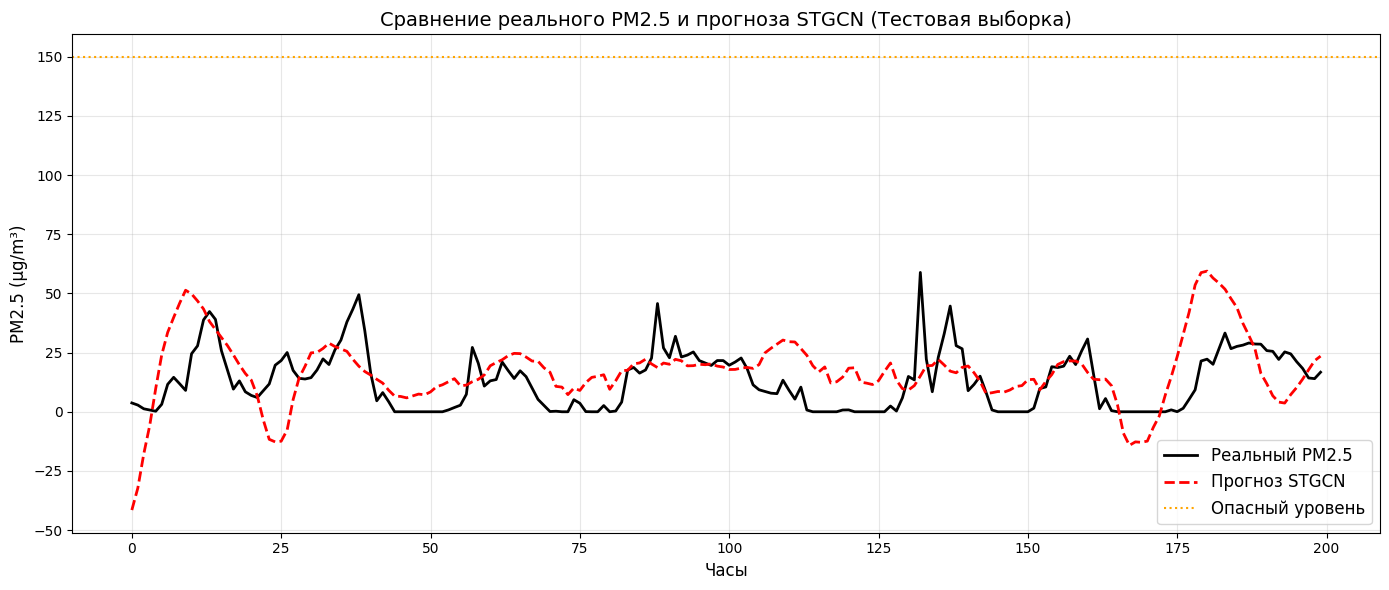

In [11]:
# 7. Визуализация
STATION_INDEX = 15
HOURS_TO_PLOT = min(200, len(real_trues)) 

plt.figure(figsize=(14, 6))
plt.plot(real_trues[:HOURS_TO_PLOT, STATION_INDEX], label="Реальный PM2.5", color='black', linewidth=2)
plt.plot(real_preds[:HOURS_TO_PLOT, STATION_INDEX], label="Прогноз STGCN", color='red', linestyle='--', linewidth=2)

plt.title("Сравнение реального PM2.5 и прогноза STGCN (Тестовая выборка)", fontsize=14)
plt.xlabel("Часы", fontsize=12)
plt.ylabel("PM2.5 (µg/m³)", fontsize=12)
plt.axhline(y=150, color='orange', linestyle=':', label="Опасный уровень")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Сохраняем прямо в артефакты
plt.savefig("artifacts/forecast_plot.png", dpi=300)
print("График сохранен в artifacts/forecast_plot.png")